# 🩸 HemaVision: Explainable AI for White Blood Cell Classification
**Architecture:** EfficientNetV2-B0 + CBAM Attention  
**Dataset:** Raabin WBC (5 Classes) — Kaggle  
**Target:** 93–97% Accuracy with Grad-CAM + Clinical Decision Support

---


## ⚙️ Cell 1: Install Dependencies

In [ ]:
# Install required libraries
!pip install -q timm grad-cam torchmetrics matplotlib seaborn scikit-learn
!pip install -q fpdf2 Pillow

import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import timm

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')
print(f'✅ PyTorch: {torch.__version__}')
print(f'✅ CUDA available: {torch.cuda.is_available()}')

✅ Device: cpu
✅ PyTorch: 2.10.0+cpu
✅ CUDA available: False


In [ ]:
from pathlib import Path
import os

BASE = Path('/kaggle/input/datasets/raabindata/raabin-wbc')

# 6 level deep দেখো
for root, dirs, files in os.walk(BASE):
    depth = len(Path(root).relative_to(BASE).parts)
    if depth > 6: continue
    indent = '  ' * depth
    nf = len(files)
    print(f'{indent}{Path(root).name}/  {"→ "+str(nf)+" files" if nf > 0 else ""}')

raabin-wbc/  
  TestB/  
    Test-B/  
      Neutrophil/  → 1971 files
      Lymphocyte/  → 148 files
  TestA/  
    TestA/  
      Monocyte/  → 234 files
      Neutrophil/  → 2660 files
      Basophil/  → 89 files
      Lymphocyte/  → 1034 files
      Eosinophil/  → 322 files
  Train/  
    Train/  
      Monocyte/  → 561 files
      Neutrophil/  → 6231 files
      Basophil/  → 212 files
      Lymphocyte/  → 2427 files
      Eosinophil/  → 744 files


## 📂 Cell 2: Dataset Exploration

Dataset path: /kaggle/input/datasets/raabindata/raabin-wbc
Exists: True

📊 Dataset Class Distribution — Raabin WBC
  Basophil    : 301 images
  Eosinophil  : 1066 images
  Lymphocyte  : 3609 images
  Monocyte    : 795 images
  Neutrophil  : 10862 images
  TOTAL       : 16633 images


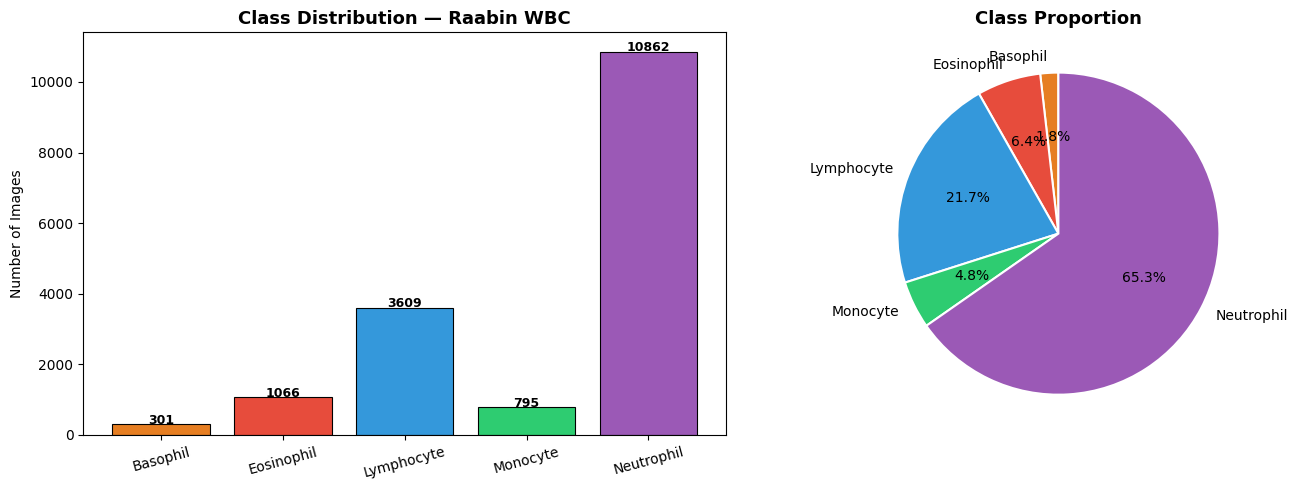

✅ Distribution plot saved.


In [ ]:
import os
from pathlib import Path

CLASSES   = ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}
IDX2CLASS = {i: c for c, i in CLASS2IDX.items()}

# Raabin WBC dataset path (same structure as paultimothymooney/blood-cells)
BASE_INPUT = Path('/kaggle/input/datasets/raabindata/raabin-wbc')

SPLIT_PATHS = [
    BASE_INPUT / 'Train' / 'Train',
    BASE_INPUT / 'TestA' / 'TestA',
    BASE_INPUT / 'TestB' / 'Test-B',
]

print(f'Dataset path: {BASE_INPUT}')
print(f'Exists: {BASE_INPUT.exists()}')
print()

class_counts = {}
for cls in CLASSES:
    count = 0
    for sp in SPLIT_PATHS:
        folder = sp / cls
        if folder.exists():
            for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp']:
                count += sum(1 for _ in folder.glob(ext))
    class_counts[cls] = count

print('=' * 50)
print('📊 Dataset Class Distribution — Raabin WBC')
print('=' * 50)
for cls in CLASSES:
    print(f'  {cls:12s}: {class_counts[cls]} images')
print(f'  {"TOTAL":12s}: {sum(class_counts.values())} images')

if sum(class_counts.values()) == 0:
    print('\n❌ 0 images — printing actual /kaggle/input structure:')
    for root, dirs, files in os.walk('/kaggle/input/'):
        depth = len(Path(root).relative_to('/kaggle/input/').parts)
        if depth > 4: continue
        indent = '  ' * depth
        nf = len(files)
        print(f'{indent}{Path(root).name}/{"  → "+str(nf)+" files" if nf else ""}')
else:
    colors = ['#E67E22', '#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.bar(class_counts.keys(), class_counts.values(),
            color=colors, edgecolor='black', linewidth=0.8)
    ax1.set_title('Class Distribution — Raabin WBC', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Number of Images')
    ax1.tick_params(axis='x', rotation=15)
    for bar, val in zip(ax1.patches, class_counts.values()):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10,
                 str(val), ha='center', fontweight='bold', fontsize=9)

    non_zero = {k: v for k, v in class_counts.items() if v > 0}
    nz_colors = [colors[CLASSES.index(k)] for k in non_zero]
    ax2.pie(non_zero.values(), labels=non_zero.keys(),
            colors=nz_colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax2.set_title('Class Proportion', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.savefig('/kaggle/working/class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Distribution plot saved.')


## 🖼️ Cell 3: Sample Image Visualization

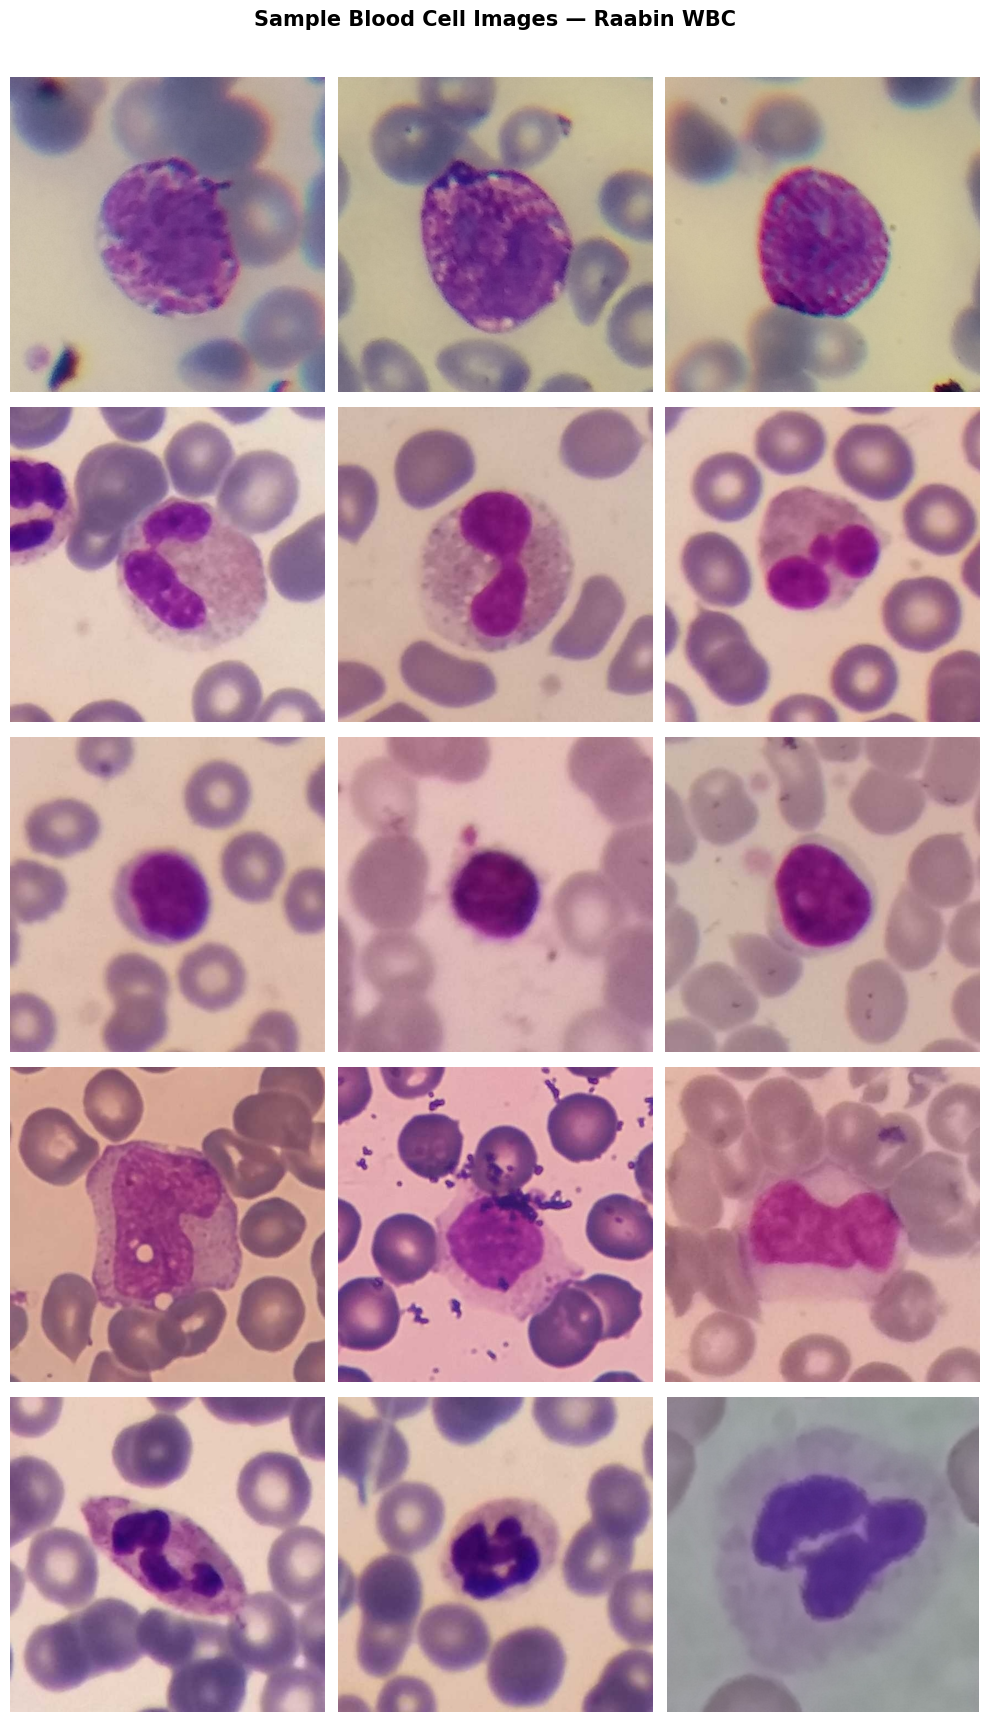

✅ Sample images saved.


In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(10, 17))
fig.suptitle('Sample Blood Cell Images — Raabin WBC',
             fontsize=15, fontweight='bold', y=1.01)

for row, cls in enumerate(CLASSES):
    cls_imgs = train_df[train_df['label'] == CLASS2IDX[cls]]['path'].tolist()[:3]
    for col, img_path in enumerate(cls_imgs):
        img = Image.open(img_path).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=9, fontweight='bold',
                                      rotation=0, labelpad=90, va='center')

plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sample images saved.')


## 🗂️ Cell 4: Build File-Path DataFrame + Stratified Split

In [ ]:
records = []

BASE = Path('/kaggle/input/datasets/raabindata/raabin-wbc')

SPLIT_PATHS = [
    BASE / 'Train' / 'Train',
    BASE / 'TestA' / 'TestA',
    BASE / 'TestB' / 'Test-B',
]

for split_path in SPLIT_PATHS:
    if not split_path.exists():
        print(f'⚠ Not found: {split_path}')
        continue
    for cls in CLASSES:
        folder = split_path / cls
        if not folder.exists():
            continue
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp']:
            for img_path in folder.glob(ext):
                records.append({'path': str(img_path), 'label': CLASS2IDX[cls]})

df = pd.DataFrame(records).drop_duplicates('path')
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f'Total images: {len(df)}')
print(df['label'].value_counts().rename(IDX2CLASS))

# Stratified 70/15/15
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED
)
print(f'\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print('Train class dist:', train_df['label'].value_counts().sort_index().to_dict())
print('Val   class dist:', val_df['label'].value_counts().sort_index().to_dict())
print('Test  class dist:', test_df['label'].value_counts().sort_index().to_dict())


Total images: 16633
label
Neutrophil    10862
Lymphocyte     3609
Eosinophil     1066
Monocyte        795
Basophil        301
Name: count, dtype: int64

Train: 11643 | Val: 2495 | Test: 2495
Train class dist: {0: 211, 1: 746, 2: 2526, 3: 557, 4: 7603}
Val   class dist: {0: 45, 1: 160, 2: 541, 3: 119, 4: 1630}
Test  class dist: {0: 45, 1: 160, 2: 542, 3: 119, 4: 1629}


## 🔄 Cell 5: Dataset & DataLoader with Augmentation

In [ ]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.10)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class BloodCellDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, int(row['label'])

# WeightedRandomSampler
class_sample_counts = train_df['label'].value_counts().sort_index().values
weights_per_class   = 1.0 / class_sample_counts
sample_weights      = train_df['label'].map(lambda l: weights_per_class[l]).values
sampler             = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_ds = BloodCellDataset(train_df, train_transform)
val_ds   = BloodCellDataset(val_df,   val_transform)
test_ds  = BloodCellDataset(test_df,  val_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'✅ Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)} batches')

✅ Train: 364 | Val: 78 | Test: 78 batches


## 🏗️ Cell 6: HemaVision Model — EfficientNetV2-B0 + CBAM

In [ ]:
# ── CBAM: Convolutional Block Attention Module
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        hidden = max(in_channels // reduction, 4)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_channels, hidden, bias=False),
            nn.ReLU(),
            nn.Linear(hidden, in_channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.fc(self.avg_pool(x))
        mx  = self.fc(self.max_pool(x))
        return x * self.sigmoid(avg + mx).unsqueeze(-1).unsqueeze(-1)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg    = x.mean(dim=1, keepdim=True)
        mx, _  = x.max(dim=1, keepdim=True)
        sa     = self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return x * sa


class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(in_channels, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        return self.sa(self.ca(x))


# ── HemaVision Model
class HemaVision(nn.Module):
    def __init__(self, num_classes=len(CLASSES), drop_rate=0.4):
        super().__init__()
        self.backbone = timm.create_model(
            'tf_efficientnetv2_b0',
            pretrained=True,
            features_only=True,
            out_indices=[4],
        )

        # Early layers freeze — blocks 0, 1, 2 frozen
        # blocks 3, 4, 5 trainable (deeper, more task-specific)
        for name, param in self.backbone.named_parameters():
            if any(f'blocks.{i}' in name for i in [0, 1, 2]):
                param.requires_grad = False

        with torch.no_grad():
            dummy   = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            feat_ch = self.backbone(dummy)[0].shape[1]

        self.cbam  = CBAM(feat_ch, reduction=16)
        self.pool  = nn.AdaptiveAvgPool2d(1)
        self.drop1 = nn.Dropout(drop_rate)

        self.head = nn.Sequential(
            nn.Linear(feat_ch, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(drop_rate / 2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        feats = self.backbone(x)[0]
        feats = self.cbam(feats)
        feats = self.pool(feats).flatten(1)
        feats = self.drop1(feats)
        return self.head(feats)

    def get_features(self, x):
        with torch.no_grad():
            feats = self.backbone(x)[0]
            feats = self.cbam(feats)
            feats = self.pool(feats).flatten(1)
        return feats

    def unfreeze_all(self):
        for param in self.backbone.parameters():
            param.requires_grad = True
        print('✅ All backbone layers unfrozen.')


# ── Instantiate
model = HemaVision(num_classes=5, drop_rate=0.4).to(DEVICE)

# ── Parameter count
total_params    = sum(p.numel() for p in model.parameters())
train_params    = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params   = total_params - train_params

print(f'✅ HemaVision created')
print(f'   Total params    : {total_params:,}')
print(f'   Trainable params: {train_params:,}')
print(f'   Frozen params   : {frozen_params:,}')

# Quick forward pass
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
out   = model(dummy)
print(f'   Output shape    : {out.shape}')

model.safetensors:   0%|          | 0.00/28.8M [00:00<?, ?B/s]

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


✅ HemaVision created
   Total params    : 5,666,295
   Trainable params: 5,472,919
   Frozen params   : 193,376
   Output shape    : torch.Size([2, 5])


## 🎯 Cell 7: Training Setup — Loss, Optimizer, Scheduler

In [ ]:
# Label smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

backbone_params = list(model.backbone.parameters()) + list(model.cbam.parameters())
head_params     = list(model.pool.parameters()) + list(model.head.parameters()) + \
                  list(model.drop1.parameters())

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 2e-4},
    {'params': head_params,     'lr': 1e-3},
], weight_decay=1e-4)

NUM_EPOCHS = 10
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

print('✅ Criterion : CrossEntropyLoss (label_smoothing=0.05)')
print('✅ Optimizer : AdamW (backbone lr=2e-4, head lr=1e-3)')
print('✅ Scheduler : CosineAnnealingWarmRestarts')

✅ Criterion : CrossEntropyLoss (label_smoothing=0.05)
✅ Optimizer : AdamW (backbone lr=2e-4, head lr=1e-3)
✅ Scheduler : CosineAnnealingWarmRestarts


## 🚂 Cell 8: Training Loop

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        preds = model(imgs)
        loss  = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        predicted   = preds.argmax(1)
        correct    += (predicted == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = model(imgs)
        loss  = criterion(preds, labels)
        total_loss += loss.item() * imgs.size(0)
        predicted   = preds.argmax(1)
        correct    += (predicted == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


# Training Loop
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
PATIENCE, no_improve = 3, 0

print('🚀 Training HemaVision...\n')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>9} | {"Val Acc":>8} | {"LR":>8}')
print('-' * 68)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc          = train_one_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc, _, _   = evaluate(model, val_loader, criterion)
    scheduler.step(epoch)
    if epoch == 5:
        model.unfreeze_all()
        print('🔓 Backbone unfrozen from epoch 6')

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    current_lr = optimizer.param_groups[1]['lr']
    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc*100:>8.2f}% | {vl_loss:>9.4f} | {vl_acc*100:>7.2f}% | {current_lr:.2e}')

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), '/kaggle/working/hemavision_best.pt')
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= PATIENCE:
        print(f'\n⏹  Early stopping at epoch {epoch}')
        break

print(f'\n✅ Best Validation Accuracy: {best_val_acc*100:.2f}%')

🚀 Training HemaVision...

 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc |       LR
--------------------------------------------------------------------
     1 |     0.4805 |    89.74% |    0.2631 |   98.64% | 9.76e-04
     2 |     0.3133 |    97.11% |    0.2573 |   98.76% | 9.05e-04
     3 |     0.2921 |    97.92% |    0.2581 |   98.80% | 7.94e-04
     4 |     0.2763 |    98.49% |    0.2536 |   99.04% | 6.55e-04
✅ All backbone layers unfrozen.
🔓 Backbone unfrozen from epoch 6
     5 |     0.2687 |    98.67% |    0.2561 |   98.88% | 5.01e-04
     6 |     0.2584 |    99.03% |    0.2606 |   98.84% | 3.46e-04
     7 |     0.2582 |    99.07% |    0.2639 |   98.64% | 2.07e-04

⏹  Early stopping at epoch 7

✅ Best Validation Accuracy: 99.04%


## 📈 Cell 9: Training Curves

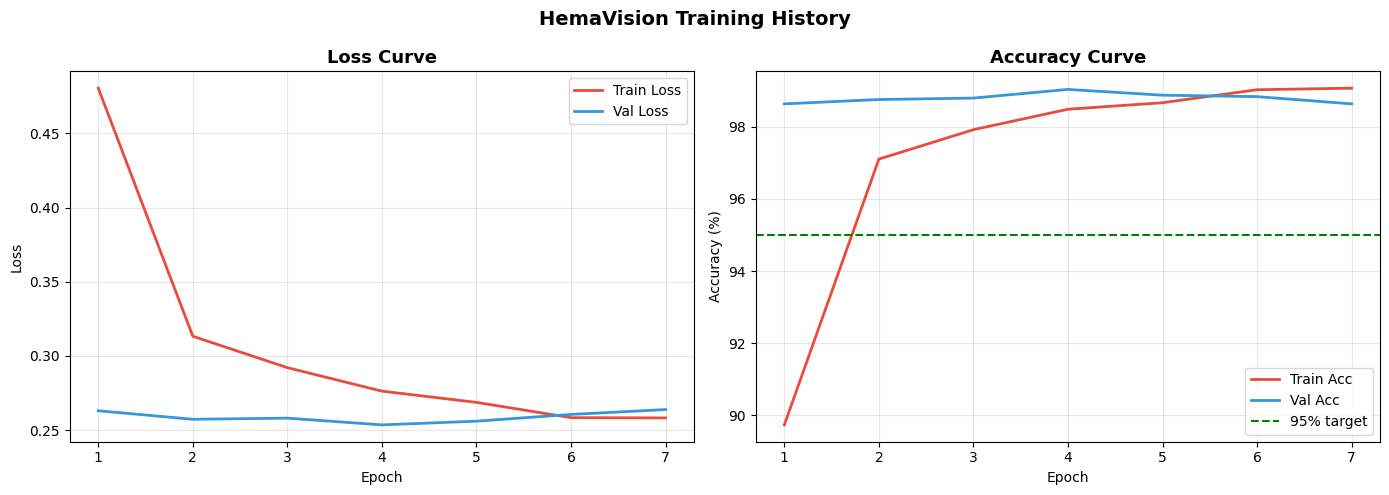

✅ Training curves saved.


In [ ]:
epochs_ran = len(history['train_loss'])
ep_range   = range(1, epochs_ran + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ep_range, history['train_loss'], label='Train Loss', color='#E74C3C', linewidth=2)
ax1.plot(ep_range, history['val_loss'],   label='Val Loss',   color='#3498DB', linewidth=2)
ax1.set_title('Loss Curve', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ep_range, [a*100 for a in history['train_acc']], label='Train Acc', color='#E74C3C', linewidth=2)
ax2.plot(ep_range, [a*100 for a in history['val_acc']],   label='Val Acc',   color='#3498DB', linewidth=2)
ax2.axhline(95, color='green', linestyle='--', linewidth=1.5, label='95% target')
ax2.set_title('Accuracy Curve', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('HemaVision Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved.')

## 🧪 Cell 10: Test Set Evaluation

In [ ]:
# Load best model
model.load_state_dict(torch.load('/kaggle/working/hemavision_best.pt', map_location=DEVICE))
model.eval()

# Run test evaluation
_, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)
print(f'🎯 Test Accuracy: {test_acc*100:.2f}%\n')

# Classification report
print('📋 Classification Report:')
print(classification_report(test_labels, test_preds, target_names=CLASSES, digits=4))

# Per-class accuracy
print('\n📊 Per-Class Accuracy:')
cm = confusion_matrix(test_labels, test_preds)
for i, cls in enumerate(CLASSES):
    cls_acc = cm[i, i] / cm[i].sum() * 100
    print(f'   {cls:12s}: {cls_acc:.2f}%')

🎯 Test Accuracy: 98.60%

📋 Classification Report:
              precision    recall  f1-score   support

    Basophil     0.9783    1.0000    0.9890        45
  Eosinophil     0.9809    0.9625    0.9716       160
  Lymphocyte     0.9762    0.9834    0.9798       542
    Monocyte     0.9478    0.9160    0.9316       119
  Neutrophil     0.9926    0.9939    0.9933      1629

    accuracy                         0.9860      2495
   macro avg     0.9752    0.9711    0.9731      2495
weighted avg     0.9859    0.9860    0.9859      2495


📊 Per-Class Accuracy:
   Basophil    : 100.00%
   Eosinophil  : 96.25%
   Lymphocyte  : 98.34%
   Monocyte    : 91.60%
   Neutrophil  : 99.39%


## 📊 Cell 11: Confusion Matrix

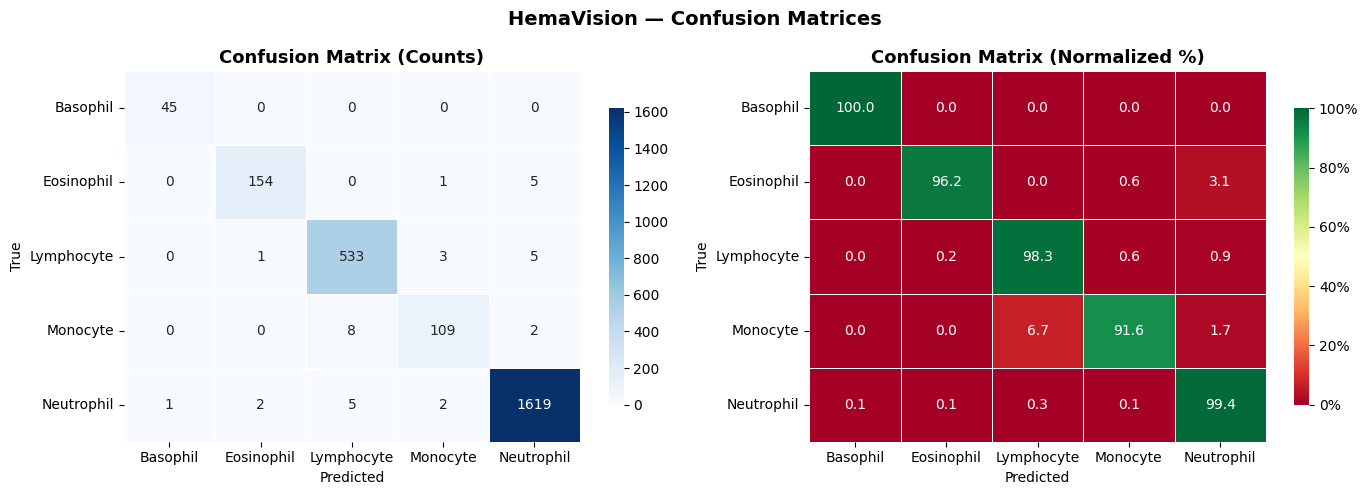

✅ Confusion matrix saved.


In [ ]:
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0],
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1],
            linewidths=0.5, cbar_kws={'shrink': 0.8, 'format': '%.0f%%'})
axes[1].set_title('Confusion Matrix (Normalized %)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle('HemaVision — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved.')

## 📉 Cell 12: ROC Curve (One-vs-Rest)

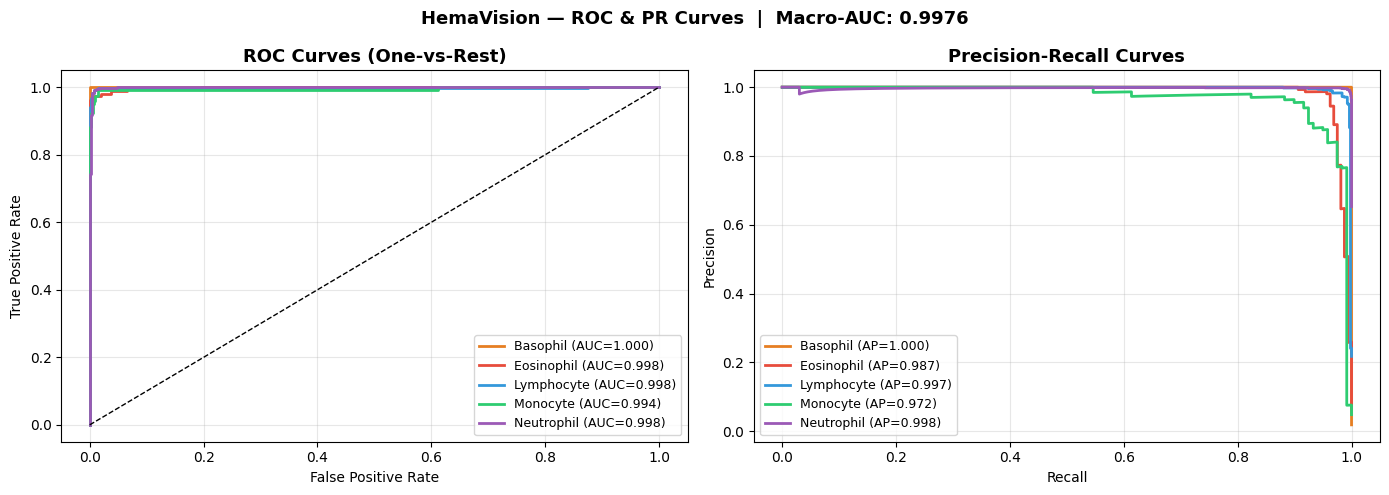

✅ ROC / PR curves saved.  Macro-AUC = 0.9976


In [ ]:
# Get softmax probabilities
all_probs, all_true = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        probs = F.softmax(model(imgs.to(DEVICE)), dim=1).cpu().numpy()
        all_probs.append(probs)
        all_true.extend(labels.numpy())

all_probs = np.vstack(all_probs)
all_true  = np.array(all_true)
true_onehot = np.eye(len(CLASSES))[all_true]

# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#E67E22', '#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

for i, (cls, col) in enumerate(zip(CLASSES, colors)):
    fpr, tpr, _ = roc_curve(true_onehot[:, i], all_probs[:, i])
    auc = roc_auc_score(true_onehot[:, i], all_probs[:, i])
    axes[0].plot(fpr, tpr, color=col, linewidth=2, label=f'{cls} (AUC={auc:.3f})')

axes[0].plot([0,1],[0,1],'k--', linewidth=1)
axes[0].set_title('ROC Curves (One-vs-Rest)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=9); axes[0].grid(True, alpha=0.3)

# Precision-Recall Curves
for i, (cls, col) in enumerate(zip(CLASSES, colors)):
    prec, rec, _ = precision_recall_curve(true_onehot[:, i], all_probs[:, i])
    ap = average_precision_score(true_onehot[:, i], all_probs[:, i])
    axes[1].plot(rec, prec, color=col, linewidth=2, label=f'{cls} (AP={ap:.3f})')

axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left', fontsize=9); axes[1].grid(True, alpha=0.3)

macro_auc = roc_auc_score(true_onehot, all_probs, average='macro')
plt.suptitle(f'HemaVision — ROC & PR Curves  |  Macro-AUC: {macro_auc:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ ROC / PR curves saved.  Macro-AUC = {macro_auc:.4f}')

## 🗺️ Cell 13: t-SNE Feature Visualization

Running t-SNE (may take ~1 min)...


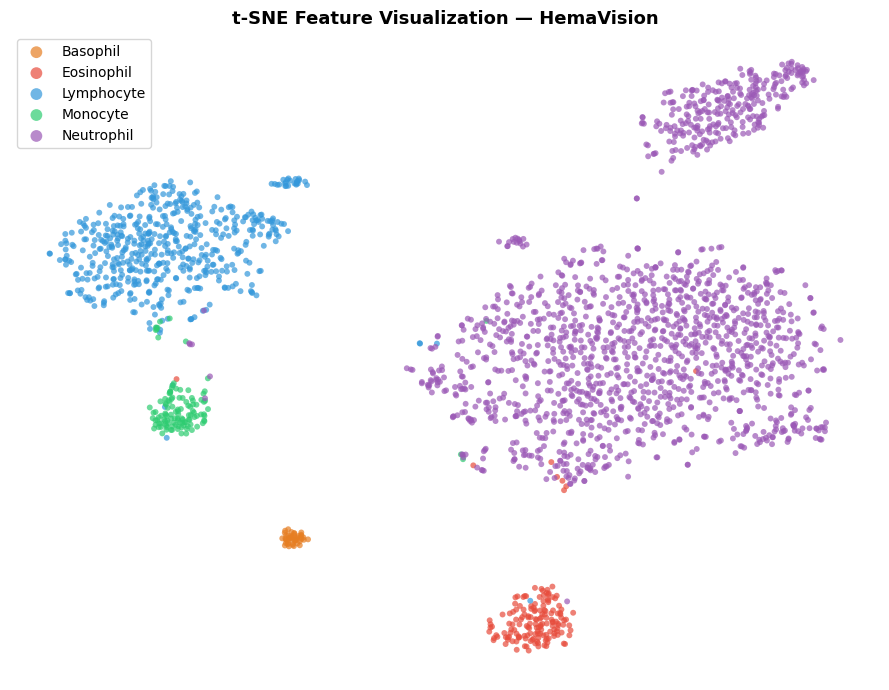

✅ t-SNE visualization saved.


In [ ]:
# Extract feature embeddings from test set
model.eval()
all_feats, all_true = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        feats = model.get_features(imgs.to(DEVICE)).cpu().numpy()
        all_feats.append(feats)
        all_true.extend(labels.numpy())

all_feats = np.vstack(all_feats)
all_true  = np.array(all_true)

print('Running t-SNE (may take ~1 min)...')
tsne = TSNE(n_components=2, perplexity=40, random_state=SEED, n_iter=1000)
emb  = tsne.fit_transform(all_feats)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#E67E22', '#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']
for i, (cls, col) in enumerate(zip(CLASSES, colors)):
    mask = all_true == i
    ax.scatter(emb[mask, 0], emb[mask, 1], c=col, label=cls,
               alpha=0.7, s=18, edgecolors='none')

ax.set_title('t-SNE Feature Visualization — HemaVision', fontsize=13, fontweight='bold')
ax.legend(markerscale=2, fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ t-SNE visualization saved.')

## 🔥 Cell 14: Grad-CAM Implementation

In [ ]:
import cv2

# Model reload
model.load_state_dict(torch.load('/kaggle/working/hemavision_best.pt', map_location=DEVICE))
model.eval()

def get_gradcam(model, img_tensor, class_idx=None):
    """Simple Grad-CAM using forward hooks only."""
    activations = {}
    gradients   = {}

    # Target: last conv layer of last block
    target = model.backbone.blocks[5][7].conv_pwl

    def fwd(m, i, o):
        activations['feat'] = o.detach()

    def bwd(m, i, o):
        gradients['grad'] = o[0].detach()

    h1 = target.register_forward_hook(fwd)
    h2 = target.register_full_backward_hook(bwd)

    # Forward
    img = img_tensor.unsqueeze(0).to(DEVICE)
    with torch.enable_grad():
        out = model(img)
        if class_idx is None:
            class_idx = out.argmax(1).item()
        model.zero_grad()
        out[0, class_idx].backward()

    h1.remove()
    h2.remove()

    # CAM
    feat = activations['feat']          # (1, C, H, W)
    grad = gradients.get('grad', None)

    if grad is not None:
        w   = grad.mean(dim=[2, 3], keepdim=True)
        cam = (w * feat).sum(dim=1, keepdim=True)
    else:
        cam = feat.mean(dim=1, keepdim=True)

    cam = F.relu(cam)
    cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE),
                        mode='bilinear', align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, class_idx


def apply_heatmap(img_pil, cam):
    img_np  = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE)))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_np, 0.5, heatmap, 0.5, 0)
    return Image.fromarray(overlay)

print('✅ Grad-CAM ready.')

✅ Grad-CAM ready.


## 🔬 Cell 15: Grad-CAM Visualization (2 samples per class)

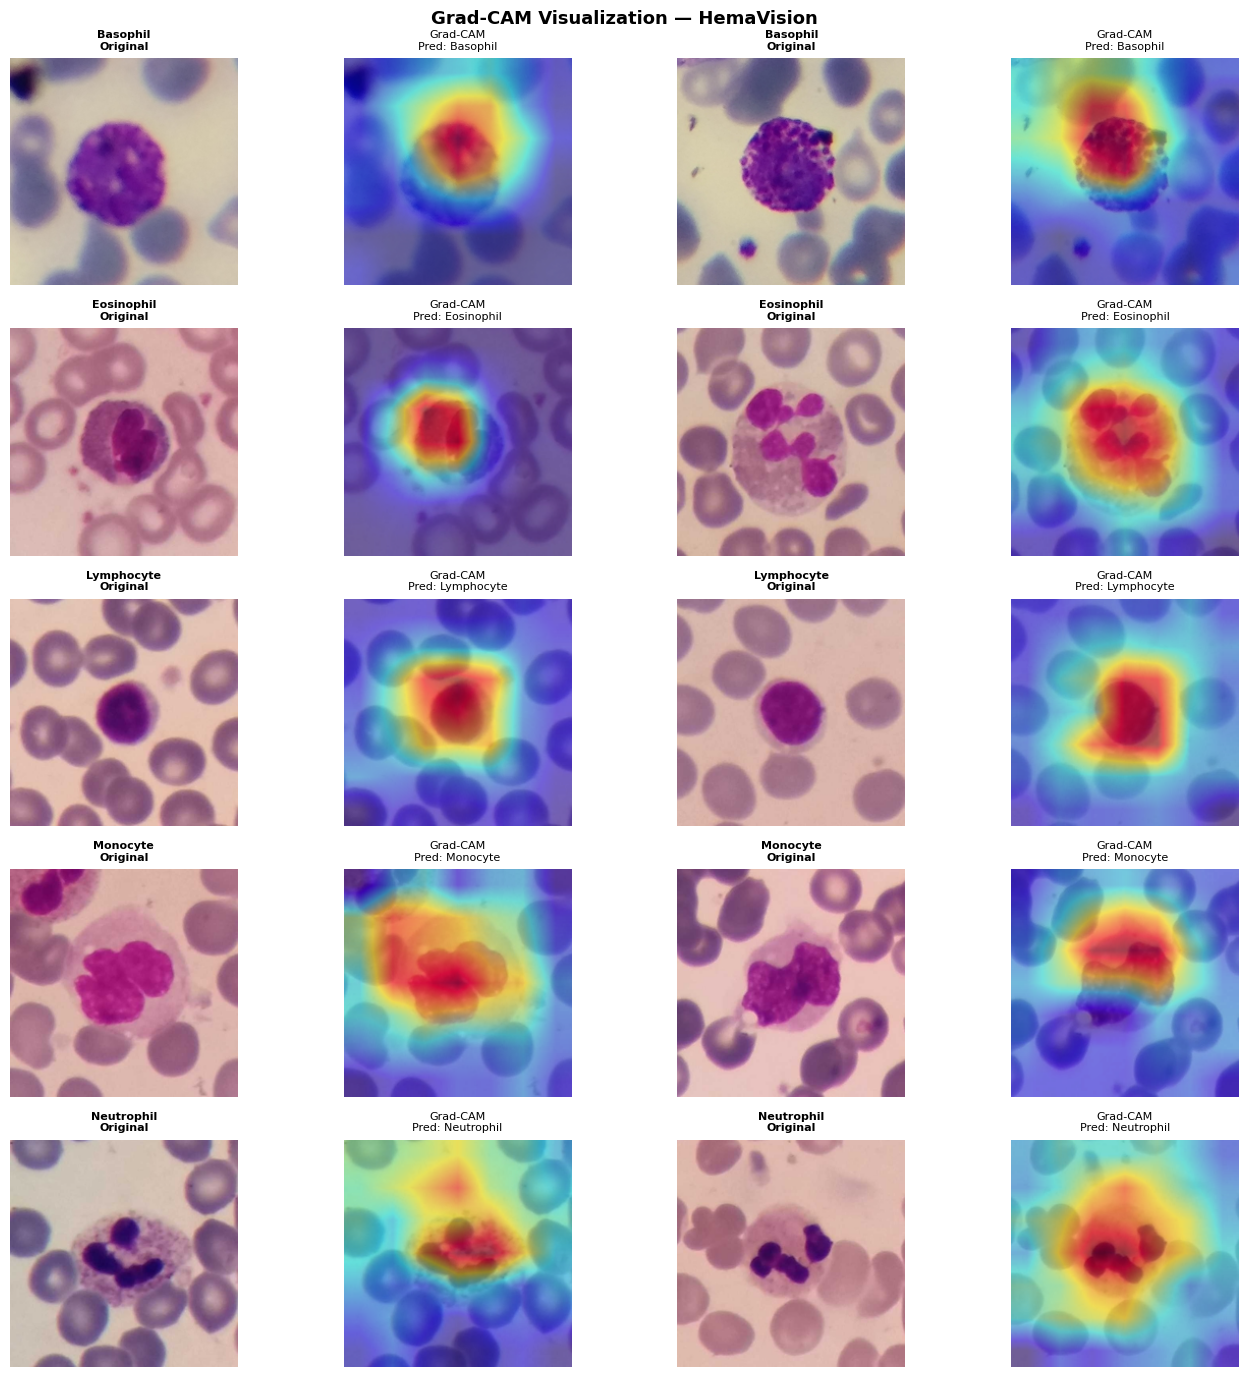

✅ Grad-CAM visualization saved.


In [ ]:
SAMPLES_PER_CLASS = 2
fig, axes = plt.subplots(len(CLASSES), SAMPLES_PER_CLASS * 2, figsize=(14, 14))
fig.suptitle('Grad-CAM Visualization — HemaVision',
             fontsize=13, fontweight='bold')

model.eval()
for row, cls_idx in enumerate(range(len(CLASSES))):
    cls_samples = test_df[test_df['label'] == cls_idx].sample(
        n=SAMPLES_PER_CLASS, random_state=row).reset_index(drop=True)

    for col, (_, sample) in enumerate(cls_samples.iterrows()):
        img_pil    = Image.open(sample['path']).convert('RGB')
        img_tensor = val_transform(img_pil)

        cam, pred_idx = get_gradcam(model, img_tensor, class_idx=cls_idx)
        overlay       = apply_heatmap(img_pil, cam)

        # Original
        axes[row, col*2].imshow(img_pil.resize((IMG_SIZE, IMG_SIZE)))
        axes[row, col*2].axis('off')
        axes[row, col*2].set_title(f'{CLASSES[cls_idx]}\nOriginal', fontsize=8, fontweight='bold')

        # Grad-CAM
        axes[row, col*2+1].imshow(overlay)
        axes[row, col*2+1].axis('off')
        axes[row, col*2+1].set_title(f'Grad-CAM\nPred: {CLASSES[pred_idx]}', fontsize=8)

plt.tight_layout()
plt.savefig('/kaggle/working/gradcam_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grad-CAM visualization saved.')

## ❌ Cell 16: Misclassification Analysis

Total misclassified: 35
Misclassification rate: 1.40%

Confusion pairs:
true_name   pred_name 
Monocyte    Lymphocyte    8
Lymphocyte  Neutrophil    5
Eosinophil  Neutrophil    5
Neutrophil  Lymphocyte    5
Lymphocyte  Monocyte      3
Monocyte    Neutrophil    2
Neutrophil  Eosinophil    2
            Monocyte      2
Eosinophil  Monocyte      1
Lymphocyte  Eosinophil    1
Neutrophil  Basophil      1


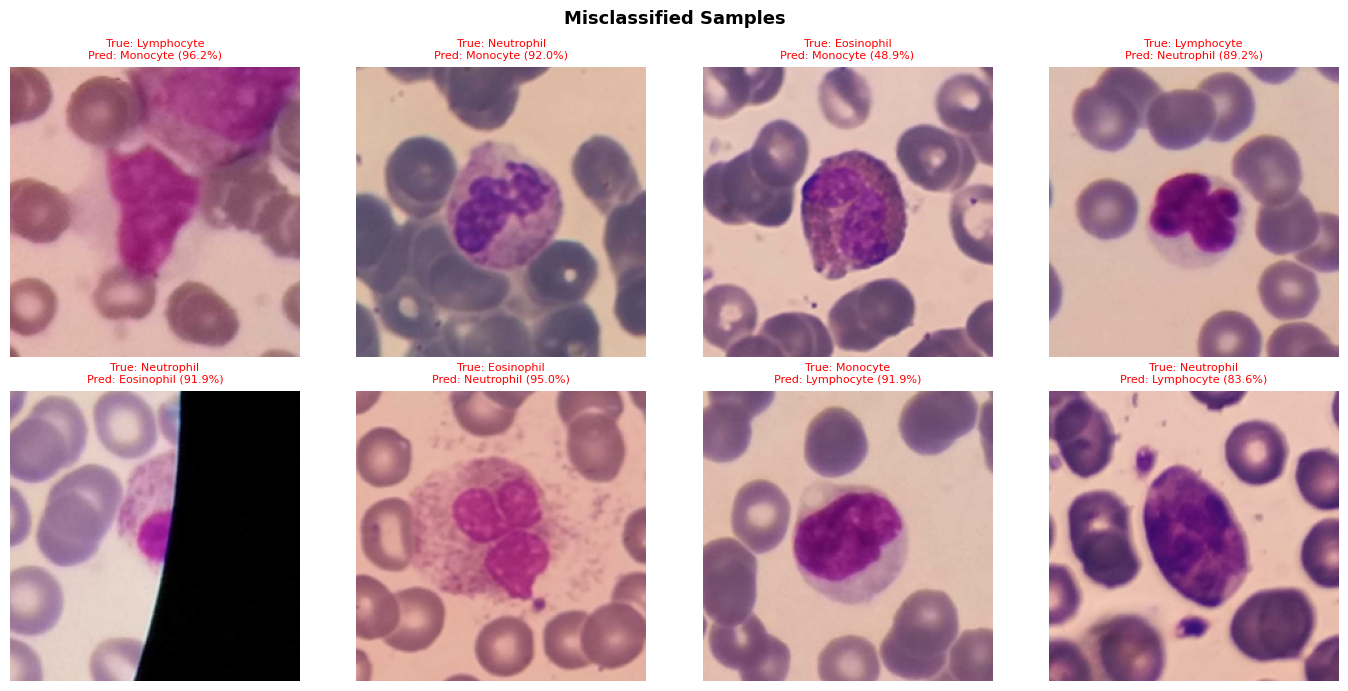

✅ Misclassification analysis done.


In [ ]:
# Find all misclassified images in test set
model.eval()
misclassified = []
sample_idx = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        probs = F.softmax(model(imgs.to(DEVICE)), dim=1).cpu()
        preds = probs.argmax(1)
        for i in range(len(labels)):
            if preds[i] != labels[i]:
                misclassified.append({
                    'idx': sample_idx + i,
                    'true': labels[i].item(),
                    'pred': preds[i].item(),
                    'conf': probs[i, preds[i]].item(),
                })
        sample_idx += len(labels)

print(f'Total misclassified: {len(misclassified)}')
print(f'Misclassification rate: {len(misclassified)/len(test_df)*100:.2f}%')

# ── Guard: misclassification না থাকলে gracefully handle করো
if len(misclassified) == 0:
    print('\n🎉 Perfect classification — no misclassified samples in test set!')
    print('✅ Misclassification analysis done.')
else:
    miss_df = pd.DataFrame(misclassified)
    miss_df['true_name'] = miss_df['true'].map(IDX2CLASS)
    miss_df['pred_name'] = miss_df['pred'].map(IDX2CLASS)

    print('\nConfusion pairs:')
    print(miss_df.groupby(['true_name', 'pred_name']).size()
          .sort_values(ascending=False).to_string())

    # Visualize
    n_show = min(8, len(misclassified))
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()
    for k in range(n_show):
        m    = misclassified[k]
        path = test_df.iloc[m['idx']]['path']
        img  = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        axes[k].imshow(img)
        axes[k].axis('off')
        axes[k].set_title(
            f'True: {IDX2CLASS[m["true"]]}\nPred: {IDX2CLASS[m["pred"]]} ({m["conf"]*100:.1f}%)',
            fontsize=8, color='red'
        )
    for k in range(n_show, len(axes)):
        axes[k].axis('off')

    plt.suptitle('Misclassified Samples', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/misclassifications.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Misclassification analysis done.')

## 📋 Cell 17: Clinical Interpretation Dictionary

In [ ]:
# Clinical metadata — for display in app
CLINICAL_INFO = {
    'Basophil': {
        'role': 'Releases histamine during allergic reactions and inflammation',
        'normal_range': '0.5–1% of WBCs (20–100 cells/µL)',
        'high': 'Basophilia — allergic reactions, hypothyroidism, CML',
        'low': 'Basopenia — acute infection, hyperthyroidism, stress',
        'morphology': 'Large dark purple granules obscuring the nucleus',
        'color': '#E67E22',
        'emoji': '🟠',
    },
    'Eosinophil': {
        'role': 'Combats parasitic infections and regulates allergic responses',
        'normal_range': '1–4% of WBCs (100–400 cells/µL)',
        'high': 'Eosinophilia — allergies, asthma, parasitic infection, autoimmune disease',
        'low': 'Eosinopenia — acute bacterial infection, Cushing syndrome',
        'morphology': 'Bilobed nucleus, pink granules in cytoplasm',
        'color': '#E74C3C',
        'emoji': '🔴',
    },
    'Lymphocyte': {
        'role': 'Adaptive immunity — T cells (cell-mediated), B cells (antibody production)',
        'normal_range': '20–40% of WBCs (1000–4800 cells/µL)',
        'high': 'Lymphocytosis — viral infections (EBV, CMV), lymphocytic leukemia',
        'low': 'Lymphocytopenia — HIV/AIDS, immunosuppressive therapy, sepsis',
        'morphology': 'Large nucleus occupying most of cell, scant blue cytoplasm',
        'color': '#3498DB',
        'emoji': '🔵',
    },
    'Monocyte': {
        'role': 'Phagocytosis of pathogens and cellular debris; antigen presentation',
        'normal_range': '2–8% of WBCs (200–800 cells/µL)',
        'high': 'Monocytosis — chronic infections (TB), inflammatory diseases, monocytic leukemia',
        'low': 'Monocytopenia — aplastic anemia, glucocorticoid therapy',
        'morphology': 'Kidney-shaped or horseshoe nucleus, abundant gray-blue cytoplasm',
        'color': '#2ECC71',
        'emoji': '🟢',
    },
    'Neutrophil': {
        'role': 'First-line immune defense — rapid phagocytosis of bacteria and fungi',
        'normal_range': '50–70% of WBCs (2500–8000 cells/µL)',
        'high': 'Neutrophilia — bacterial infection, tissue injury, steroid use',
        'low': 'Neutropenia — viral infection, chemotherapy, aplastic anemia',
        'morphology': 'Multi-lobed nucleus (3–5 lobes), granular purple cytoplasm',
        'color': '#9B59B6',
        'emoji': '🟣',
    },
}

print('✅ Clinical interpretation dictionary loaded.')
print(f'   Classes covered: {list(CLINICAL_INFO.keys())}')


✅ Clinical interpretation dictionary loaded.
   Classes covered: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']


## 🩺 Cell 18: Single Image Prediction with Clinical Report

🔬 Predicting: /kaggle/input/datasets/raabindata/raabin-wbc/Train/Train/Neutrophil/95-8-13-4_240_1.jpg


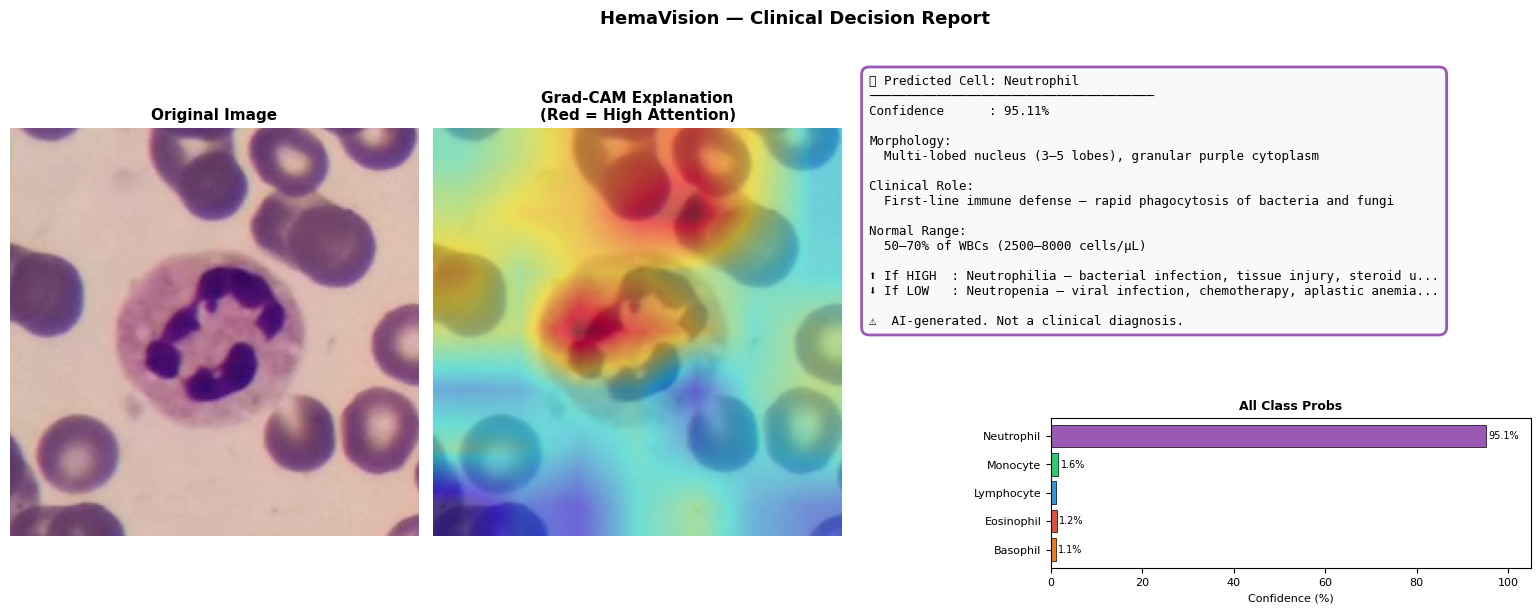


🎯 Result: Neutrophil  (95.11%)


In [ ]:
def predict_single(image_path, show_gradcam=True):
    """
    Predict cell type for a single image.
    Returns prediction, confidence, Grad-CAM overlay, and clinical info.
    """
    model.eval()
    img_pil = Image.open(image_path).convert('RGB')
    img_tensor = val_transform(img_pil)

    with torch.no_grad():
        probs = F.softmax(model(img_tensor.unsqueeze(0).to(DEVICE)), dim=1)[0].cpu().numpy()

    pred_idx  = probs.argmax()
    pred_cls  = IDX2CLASS[pred_idx]
    confidence = probs[pred_idx] * 100

    # Grad-CAM
    cam, _ = get_gradcam(model, img_tensor, class_idx=int(pred_idx))
    overlay = apply_heatmap(img_pil, cam)

    # ── Visualization
    if show_gradcam:
        info = CLINICAL_INFO[pred_cls]
        fig = plt.figure(figsize=(16, 6))
        gs  = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1.5])

        # Original
        ax0 = fig.add_subplot(gs[0])
        ax0.imshow(img_pil.resize((IMG_SIZE, IMG_SIZE)))
        ax0.set_title('Original Image', fontsize=11, fontweight='bold')
        ax0.axis('off')

        # Grad-CAM
        ax1 = fig.add_subplot(gs[1])
        ax1.imshow(overlay)
        ax1.set_title('Grad-CAM Explanation\n(Red = High Attention)', fontsize=11, fontweight='bold')
        ax1.axis('off')

        # Clinical info
        ax2 = fig.add_subplot(gs[2])
        ax2.axis('off')
        report_text = (
            f"{info['emoji']} Predicted Cell: {pred_cls}\n"
            f"{'─'*38}\n"
            f"Confidence      : {confidence:.2f}%\n\n"
            f"Morphology:\n  {info['morphology']}\n\n"
            f"Clinical Role:\n  {info['role']}\n\n"
            f"Normal Range:\n  {info['normal_range']}\n\n"
            f"⬆ If HIGH  : {info['high'][:60]}...\n"
            f"⬇ If LOW   : {info['low'][:60]}...\n\n"
            f"⚠  AI-generated. Not a clinical diagnosis."
        )
        ax2.text(0.02, 0.98, report_text, transform=ax2.transAxes,
                 fontsize=9, verticalalignment='top', fontfamily='monospace',
                 bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8f9fa', edgecolor=info['color'], linewidth=2))

        # Probability bar chart inset
        ax_bar = fig.add_axes([0.66, 0.08, 0.30, 0.25])
        bar_colors = [CLINICAL_INFO[IDX2CLASS[i]]['color'] for i in range(len(CLASSES))]
        bars = ax_bar.barh(CLASSES, probs * 100, color=bar_colors, edgecolor='black', linewidth=0.5)
        ax_bar.set_xlabel('Confidence (%)', fontsize=8)
        ax_bar.set_title('All Class Probs', fontsize=9, fontweight='bold')
        ax_bar.tick_params(labelsize=8)
        ax_bar.set_xlim(0, 105)
        for bar, val in zip(bars, probs * 100):
            if val > 1:
                ax_bar.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                            f'{val:.1f}%', va='center', fontsize=7)

        plt.suptitle('HemaVision — Clinical Decision Report', fontsize=13, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.savefig('/kaggle/working/single_prediction_report.png', dpi=150, bbox_inches='tight')
        plt.show()

    return {'class': pred_cls, 'confidence': confidence, 'probs': dict(zip(CLASSES, probs))}


# ── Demo: pick one test image
demo_path = test_df.iloc[0]['path']
print(f'🔬 Predicting: {demo_path}')
result = predict_single(demo_path)
print(f'\n🎯 Result: {result["class"]}  ({result["confidence"]:.2f}%)')

## 🍕 Cell 19: Batch Distribution Analysis (Multi-Upload Feature)

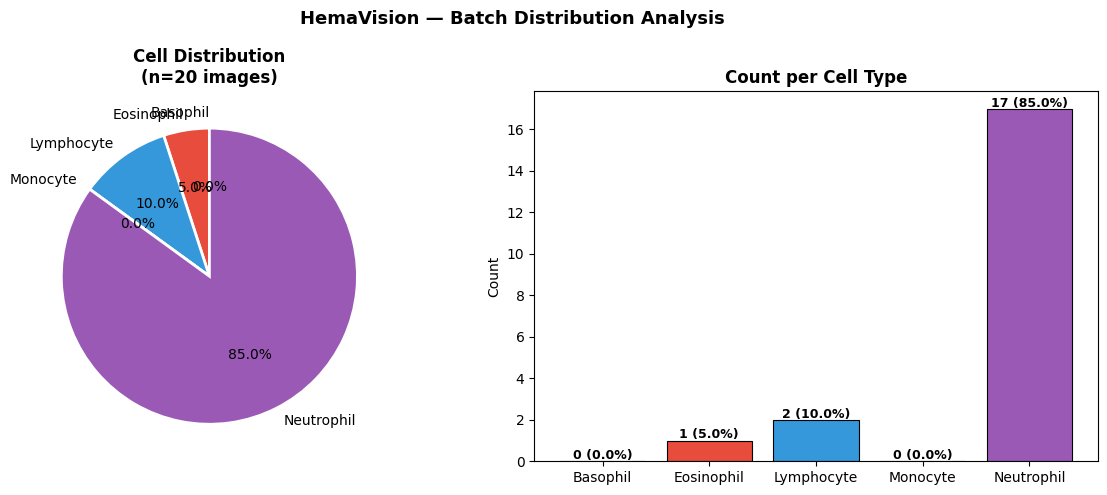


📊 Summary:
  🟠 Basophil    :   0 (  0.0%)
  🔴 Eosinophil  :   1 (  5.0%)
  🔵 Lymphocyte  :   2 ( 10.0%)
  🟢 Monocyte    :   0 (  0.0%)
  🟣 Neutrophil  :  17 ( 85.0%)
✅ Batch analysis complete.


In [ ]:
def batch_distribution_analysis(image_paths):
    """
    Analyze cell distribution across multiple images.
    Mimics Streamlit multi-upload feature.
    """
    model.eval()
    class_counts = {cls: 0 for cls in CLASSES}
    results = []

    for path in image_paths:
        try:
            img_tensor = val_transform(Image.open(path).convert('RGB'))
            with torch.no_grad():
                probs = F.softmax(model(img_tensor.unsqueeze(0).to(DEVICE)), dim=1)[0].cpu().numpy()
            pred_cls = IDX2CLASS[probs.argmax()]
            class_counts[pred_cls] += 1
            results.append({'path': path, 'prediction': pred_cls, 'confidence': probs.max() * 100})
        except Exception as e:
            print(f'Error processing {path}: {e}')

    total = sum(class_counts.values())

    # Plot distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    pcts  = {k: v/total*100 for k, v in class_counts.items()}
    cols  = [CLINICAL_INFO[c]['color'] for c in CLASSES]

    ax1.pie([pcts[c] for c in CLASSES], labels=CLASSES, colors=cols,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax1.set_title(f'Cell Distribution\n(n={total} images)', fontsize=12, fontweight='bold')

    bars = ax2.bar(CLASSES, [class_counts[c] for c in CLASSES], color=cols,
                  edgecolor='black', linewidth=0.8)
    ax2.set_title('Count per Cell Type', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Count')
    for bar, c in zip(bars, CLASSES):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{class_counts[c]} ({pcts[c]:.1f}%)', ha='center', fontsize=9, fontweight='bold')

    plt.suptitle('HemaVision — Batch Distribution Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/batch_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n📊 Summary:')
    for cls in CLASSES:
        print(f'  {CLINICAL_INFO[cls]["emoji"]} {cls:12s}: {class_counts[cls]:3d} ({pcts[cls]:5.1f}%)')

    return results


# Demo: 20 random test images
demo_paths = test_df.sample(20, random_state=SEED)['path'].tolist()
batch_results = batch_distribution_analysis(demo_paths)
print('✅ Batch analysis complete.')

## 📊 Cell 21: Final Summary Dashboard

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Recalculate test metrics
_, final_acc, final_preds, final_labels = evaluate(model, test_loader, criterion)
f1     = f1_score(final_labels, final_preds, average='weighted')
prec   = precision_score(final_labels, final_preds, average='weighted')
rec    = recall_score(final_labels, final_preds, average='weighted')
m_auc  = roc_auc_score(np.eye(len(CLASSES))[np.array(final_labels)], all_probs, average='macro')

print('=' * 55)
print('        🩸 HemaVision — Final Results Summary')
print('=' * 55)
print(f'  Architecture  : EfficientNetV2-B0 + CBAM Attention')
print(f'  Dataset       : Raabin WBC ({len(CLASSES)} classes)')
print(f'  Test Accuracy : {final_acc*100:.2f}%')
print(f'  Weighted F1   : {f1:.4f}')
print(f'  Precision     : {prec:.4f}')
print(f'  Recall        : {rec:.4f}')
print(f'  Macro AUC     : {m_auc:.4f}')
print('=' * 55)
print()

# Per-class
print('  Per-Class Accuracy:')
cm = confusion_matrix(final_labels, final_preds)
for i, cls in enumerate(CLASSES):
    print(f'    {CLINICAL_INFO[cls]["emoji"]} {cls:12s}: {cm[i,i]/cm[i].sum()*100:.2f}%')

print()
print('  Saved outputs:')
saved = [
    'class_distribution.png', 'sample_images.png', 'training_curves.png',
    'confusion_matrix.png', 'roc_pr_curves.png', 'tsne_visualization.png',
    'gradcam_visualization.png', 'misclassifications.png',
    'batch_distribution.png', 'single_prediction_report.png',
    'hemavision_report.pdf', 'hemavision_best.pt',
]
for f in saved:
    p = Path(f'/kaggle/working/{f}')
    status = '✅' if p.exists() else '❌'
    print(f'    {status} {f}')

        🩸 HemaVision — Final Results Summary
  Architecture  : EfficientNetV2-B0 + CBAM Attention
  Dataset       : Raabin WBC (5 classes)
  Test Accuracy : 98.60%
  Weighted F1   : 0.9859
  Precision     : 0.9859
  Recall        : 0.9860
  Macro AUC     : 0.9976

  Per-Class Accuracy:
    🟠 Basophil    : 100.00%
    🔴 Eosinophil  : 96.25%
    🔵 Lymphocyte  : 98.34%
    🟢 Monocyte    : 91.60%
    🟣 Neutrophil  : 99.39%

  Saved outputs:
    ✅ class_distribution.png
    ✅ sample_images.png
    ✅ training_curves.png
    ✅ confusion_matrix.png
    ✅ roc_pr_curves.png
    ✅ tsne_visualization.png
    ✅ gradcam_visualization.png
    ✅ misclassifications.png
    ✅ batch_distribution.png
    ✅ single_prediction_report.png
    ❌ hemavision_report.pdf
    ✅ hemavision_best.pt


## 💾 Cell 22: Save Model for Streamlit Deployment

In [ ]:
# Save everything needed for deployment
deploy_package = {
    'model_state_dict': model.state_dict(),
    'classes': CLASSES,
    'class2idx': CLASS2IDX,
    'idx2class': IDX2CLASS,
    'img_size': IMG_SIZE,
    'clinical_info': CLINICAL_INFO,
    'num_classes': len(CLASSES),
    'test_accuracy': final_acc,
    'val_accuracy': best_val_acc,
}

torch.save(deploy_package, '/kaggle/working/hemavision_deploy.pt')
print('✅ Deployment package saved → /kaggle/working/hemavision_deploy.pt')
print()
print('📦 To load in Streamlit:')
print('''
  pkg   = torch.load("hemavision_deploy.pt", map_location="cpu")
  model = HemaVision(num_classes=pkg["num_classes"])
  model.load_state_dict(pkg["model_state_dict"])
  model.eval()
  CLASSES       = pkg["classes"]
  IDX2CLASS     = pkg["idx2class"]
  CLINICAL_INFO = pkg["clinical_info"]
''')

print('🎉 HemaVision training and analysis complete!')
print('Next step → Run Streamlit app using the saved model.')

✅ Deployment package saved → /kaggle/working/hemavision_deploy.pt

📦 To load in Streamlit:

  pkg   = torch.load("hemavision_deploy.pt", map_location="cpu")
  model = HemaVision(num_classes=pkg["num_classes"])
  model.load_state_dict(pkg["model_state_dict"])
  model.eval()
  CLASSES       = pkg["classes"]
  IDX2CLASS     = pkg["idx2class"]
  CLINICAL_INFO = pkg["clinical_info"]

🎉 HemaVision training and analysis complete!
Next step → Run Streamlit app using the saved model.
